<a href="https://colab.research.google.com/github/yiftachsa/AI-Advanced/blob/main/Donations_Ofer_Kalderon_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ofer Kalderon crowd funding donations analysis
A quick exploration of donations made to the crowd funding campaign for  Yarden Bibas. This analysis includes **collecting the data** by scraping the crowd-funding platform. The data is then preprocessed (standardizing time format and currency). This is followed by v**isualizations of the donations amounts over time and the amounts distribution.**

**Sentiment analysis** is used to score each English comment using **nltk's SentimentIntensityAnalyzer and DistilBert**. This is done to extract the sentiments of the comments and to evaluate briefly **whether there is a correlation between the sentiment and the donation's amount**. In other words, *whether people who comment positively donated more then people who commented negatively (from a place of pain, asking for forgiveness, etc.).*

Lastly, examinations of the **most frequent words** is done to get a quick high level insight of the overall sentiments (using tokenization and lemmatization). The **word frequencies** are used to build **words clouds**.  

#Init

In [1]:
# Install required libraries
!pip install selenium beautifulsoup4 pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.2/499.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.8/129.8 kB 9.2 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.4.0
    Uninstalling urllib3-2.4.0:
      Successfully uninstalled urllib3-2.4.0


In [2]:
# Import libraries
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup
from pprint import pprint

import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np
from datetime import datetime, timedelta
import re
import plotly.graph_objects as go

#Data

##Scraping (Collecting data)

In [25]:
# Selenium WebDriver
options = webdriver.ChromeOptions()
options.add_argument('--headless')  # browser in headless mode
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
driver = webdriver.Chrome(options=options)

# donation site
url = "https://yad.reachhands.com/oferenu"
driver.get(url)

# Automate 'Load More' button clicks
count = 0
max_calls = float('inf')

while count < max_calls:
    try:
        # Locate 'Load More' button
        load_more_button = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.ID, "loadMore"))
        )
        # button visible (if hidden)
        driver.execute_script("arguments[0].classList.remove('hide');", load_more_button)
        driver.execute_script("arguments[0].style.display = 'block';", load_more_button)

        # using JavaScript
        driver.execute_script("arguments[0].click();", load_more_button)

        # Wait for loader to appear
        WebDriverWait(driver, 10).until(
            EC.visibility_of_element_located((By.ID, "tbLoader"))
        )
        WebDriverWait(driver, 10).until(
            EC.invisibility_of_element((By.ID, "tbLoader"))
        )
        if count % 100 == 0:
            print(f"Count: {count}")
        count += 1

    except Exception as e:
        print("No more 'Load More' button or additional content available.")
        break

soup = BeautifulSoup(driver.page_source, 'html.parser')
driver.quit()
# pprint(soup.prettify())

Count: 0
Count: 100
Count: 200
Count: 300
Count: 400
Count: 500
Count: 600
Count: 700
Count: 800
Count: 900
Count: 1000
Count: 1100
No more 'Load More' button or additional content available.


##Preprocess

In [44]:
def is_date_format(s):
    # Regex for MM/DD/YYYY format
    date_pattern = re.compile(r'^\d{2}/\d{2}/\d{4}$')
    return bool(date_pattern.match(s))


def convert_relative_time(relative_time):
    is_date = is_date_format(relative_time)
    if is_date:
        return datetime.strptime(relative_time, '%d/%m/%Y').strftime("%d-%m-%Y")
    else:
      current_time = datetime.now()
      return current_time.strftime("%d-%m-%Y")

# def convert_relative_time(relative_time):
#     is_date = is_date_format(relative_time)
#     if is_date:
#         return datetime.strptime(relative_time, '%d/%m/%Y').strftime("%d-%m-%Y %H:%M")
#     current_time = datetime.now()

#     # special case: "a minute ago"
#     if relative_time == "a minute ago":
#         return (current_time - timedelta(minutes=1)).strftime("%d-%m-%Y %H:%M")

#     # regex to parse complex time strings like "16 hours and 38 minutes ago"
#     time_pattern = re.compile(r'(\d+)\s*(minute|hour|day|week)')
#     matches = time_pattern.findall(relative_time)

#     delta = timedelta()
#     for value, unit in matches:
#         value = int(value)
#         if "minute" in unit:
#             delta += timedelta(minutes=value)
#         elif "hour" in unit:
#             delta += timedelta(hours=value)
#         elif "day" in unit:
#             delta += timedelta(days=value)
#         elif "week" in unit:
#             delta += timedelta(weeks=value)

#     # Subtract the total delta from the current time
#     converted_time = current_time - delta
#     return converted_time.strftime("%d-%m-%Y %H:%M")

# Examples
# print(convert_relative_time("16 hours and 38 minutes ago"))  # Test with complex time
# print(convert_relative_time("2 days and 5 hours ago"))        # Another example
# print(convert_relative_time("a minute ago"))                 # Special case
# print(convert_relative_time("12 minutes ago"))

In [45]:
# Extract donation data
donations = []
for entry in soup.select("tr"):  # Iterate over table row
    try:
        # Parse donor name
        name = entry.select_one("td.info span.name").text.strip()
    except AttributeError:
        name = "Anonymous"

    try:
        # Parse comment
        comment = entry.select_one("td.info span.comment").text.strip()
    except AttributeError:
        comment = "No comment"

    try:
        # Parse donation amount
        amount = entry.select_one("td.details span.amount").text.strip()
    except AttributeError:
        amount = "0"

    try:
        # Parse donation time
        time = entry.select_one("td.details span.amount-time").text.strip()
    except AttributeError:
        time = "Unknown Time"

    donations.append({"Name": name, "Amount": amount, "Time": time, "Comment": comment})

df = pd.DataFrame(donations)
df['Time'] = df['Time'].replace('less than a minute ago', 'a minute ago', regex=True)
df['Time'] = df['Time'].apply(lambda x: convert_relative_time(x) if x != "Unknown Time" else x)  # Convert time to datetime
# df['Amount'] = df['Amount'].replace('[^\d.]', '', regex=True).astype(float)  # Strip non-numeric characters and convert to float

display(df)


,Name,Amount,Time,Comment
0,Elnaz Panbechi,$26,10-07-2025,Wish you much much success! We are all one fam...
1,Cécile Bensimon,$118,10-07-2025,"Please, Ofer, don’t give up. You WILL heal, yo..."
2,Diana Ben Shalom,$180,08-07-2025,בהצלחה עופר 🫶🏼
3,Anonymous,$360,08-07-2025,No comment
4,Sheri Segal Glick,$36,07-07-2025,Sending so much love to you and your family.
...,...,...,...,...
17963,נועם בוחבוט,₪360,03-07-2025,No comment
17964,דיקלה חבתן,₪250,03-07-2025,No comment
17965,דיקלה חבתן,₪250,03-07-2025,No comment
17966,נעמה נחום,₪200,03-07-2025,"עופר, כמה טוב שאתה פה"


In [46]:
# Conversion rates
conversion_rates = {
    '€': 4.2,  # Euro to NIS
    '$': 3.7,  # USD to NIS
    '£': 4.8,  # GBP to NIS
    '₪': 1.0   # NIS to NIS (no conversion needed)
}

# convert to NIS
def convert_to_nis(amount_str):
    # Remove commas and currency symbols
    for symbol in conversion_rates.keys():
        if symbol in amount_str:
            amount_str = amount_str.replace(symbol, '').replace(',', '')
            amount_value = float(amount_str)
            return amount_value * conversion_rates[symbol]
    return 0  # in case the currency is not recognized

df['Amount_in_NIS'] = df['Amount'].apply(convert_to_nis)

display(df)


,Name,Amount,Time,Comment,Amount_in_NIS
0,Elnaz Panbechi,$26,10-07-2025,Wish you much much success! We are all one fam...,96.2
1,Cécile Bensimon,$118,10-07-2025,"Please, Ofer, don’t give up. You WILL heal, yo...",436.6
2,Diana Ben Shalom,$180,08-07-2025,בהצלחה עופר 🫶🏼,666.0
3,Anonymous,$360,08-07-2025,No comment,1332.0
4,Sheri Segal Glick,$36,07-07-2025,Sending so much love to you and your family.,133.2
...,...,...,...,...,...
17963,נועם בוחבוט,₪360,03-07-2025,No comment,360.0
17964,דיקלה חבתן,₪250,03-07-2025,No comment,250.0
17965,דיקלה חבתן,₪250,03-07-2025,No comment,250.0
17966,נעמה נחום,₪200,03-07-2025,"עופר, כמה טוב שאתה פה",200.0


In [48]:
# Convert to datetime
# df['datetime'] = pd.to_datetime(df['Time'], format="%d-%m-%Y %H:%M")

# df['hour'] = df['datetime'].dt.floor('H')  # Group by the hour

df = df.sort_values(by='Time')

df['Cumulative Total'] = df['Amount_in_NIS'].cumsum()

##Visualization

###Donations over time

In [49]:
# df_last_in_hour = df.groupby('hour').last().reset_index()

# plt.figure(figsize=(12, 6))
# plt.plot(df_last_in_hour['hour'], df_last_in_hour['Cumulative Total'], label="Cumulative Donations")
# plt.xlabel("Time")
# plt.ylabel("Donation Total")
# plt.title("Donation Total Over Time")
# plt.legend()
# plt.grid(True)
# plt.show()


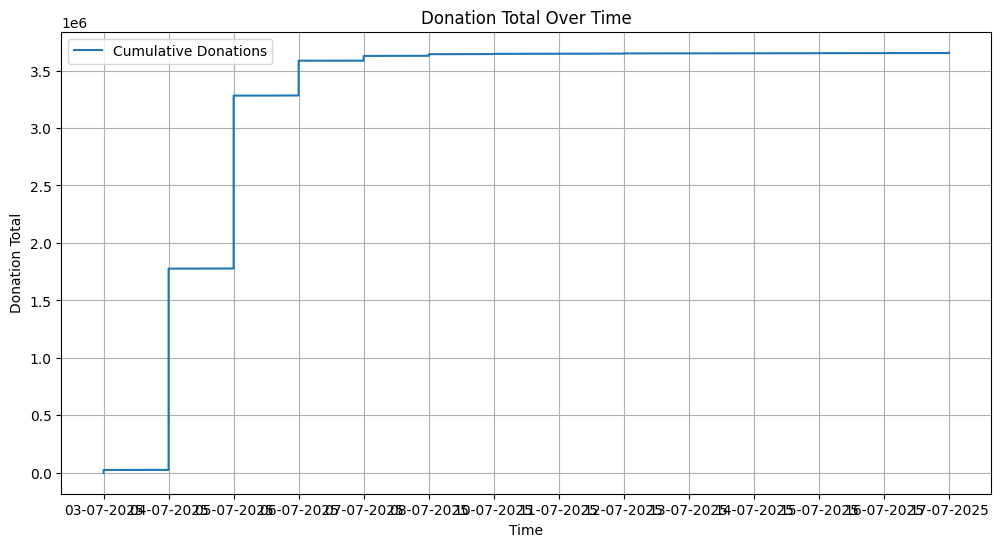

In [50]:
plt.figure(figsize=(12, 6))
plt.plot(df['Time'], df['Cumulative Total'], label="Cumulative Donations")
plt.xlabel("Time")
plt.ylabel("Donation Total")
plt.title("Donation Total Over Time")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
import plotly.express as px

# Plot cumulative sum
fig = px.line(df[::10], x='Time', y='Cumulative Total', title='Cumulative Sum over Time', labels={'Cumulative Total': 'Cumulative Amount'}, hover_data={'Amount_in_NIS': True})
fig.show()


In [52]:
# 99th percentile
top_1_quantile_thresh = np.quantile(df['Amount_in_NIS'], 0.99)
top_1_quantile = df[df['Amount_in_NIS'] > top_1_quantile_thresh]

top_0_1_quantile_thresh = np.quantile(df['Amount_in_NIS'], 0.999)
top_0_1_quantile = df[df['Amount_in_NIS'] > top_0_1_quantile_thresh]

fig = px.line(df,
              x='Time',
              y='Cumulative Total',
              title='Cumulative Sum over Time',
              labels={'Cumulative Total': 'Cumulative Amount'},
              hover_data={'Amount_in_NIS': True})

# Add scatter plot for 99th percentile outliers in orange
fig.add_trace(go.Scatter(
    x=top_1_quantile['Time'],
    y=top_1_quantile['Cumulative Total'],
    mode='markers',
    marker=dict(color='orange', size=8),
    name='top_1_quantile',
    text=top_1_quantile['Amount_in_NIS'].apply(lambda x: str(x) + " NIS"),  # Text for hover display
    # hoverinfo='text'  # Show only text in hover tooltip
))

# Add scatter plot for 99.9th percentile outliers in red
fig.add_trace(go.Scatter(
    x=top_0_1_quantile['Time'],
    y=top_0_1_quantile['Cumulative Total'],
    mode='markers',
    marker=dict(color='red', size=8),
    name='top_0.1_quantile',
    text=top_0_1_quantile['Amount_in_NIS'].apply(lambda x: str(x) + " NIS"),  # Text for hover display
    # hoverinfo='text'  # Show only text in hover tooltip
))

# Show the plot
fig.show()

###Donations Distribution - Histogram of Amount with Density Estimation

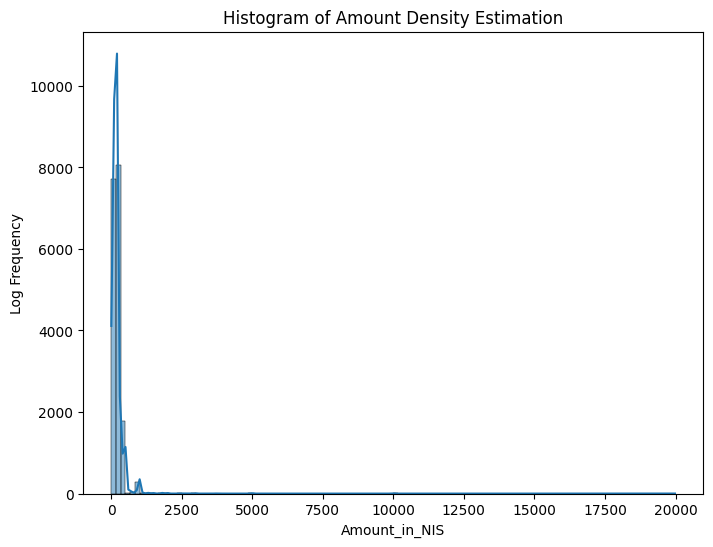

In [53]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(df['Amount_in_NIS'], kde=True, bins=120)
plt.title('Histogram of Amount Density Estimation')
plt.xlabel('Amount_in_NIS')
plt.ylabel('Log Frequency')
plt.show()

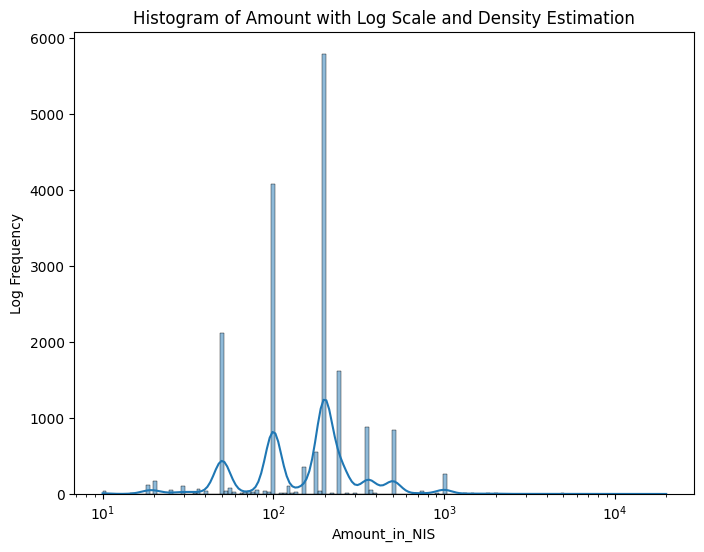

In [54]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Amount_in_NIS'], log_scale=True, kde=True)
plt.title('Histogram of Amount with Log Scale and Density Estimation')
plt.xlabel('Amount_in_NIS')
plt.ylabel('Log Frequency')
plt.show()

###Top 0.1% Donations

In [55]:
top_0_1_quantile.sort_values(by='Amount_in_NIS', ascending=False)

,Name,Amount,Time,Comment,Amount_in_NIS,Cumulative Total
240,Jorge Woldenberg,"$5,400",04-07-2025,No comment,19980.0,1254489.6
1520,Anonymous,"₪18,000",06-07-2025,No comment,18000.0,3459968.5
12174,קופאק בע״מ,"₪10,000",04-07-2025,No comment,10000.0,77007.0
17938,SQR Security Solutions LTD,"₪10,000",03-07-2025,שי סלחטר,10000.0,23492.0
16314,Anonymous,"₪10,000",04-07-2025,No comment,10000.0,1035877.0
10048,ישראל ומירב חייקין,"₪10,000",04-07-2025,אוהבים אותך!!!,10000.0,465983.0
1093,גבריאל שוקרון,"₪10,000",06-07-2025,No comment,10000.0,3514419.5
217,Niv and Laura Karmi,"$2,000",04-07-2025,No comment,7400.0,1208492.0
55,Anonymous,"$2,000",05-07-2025,No comment,7400.0,2314373.4
60,Raz & Liraz Evenor,"$1,500",05-07-2025,No comment,5550.0,2323397.7


In [56]:
df['Amount_in_NIS'].describe()

,Amount_in_NIS
count,17968.000000
mean,203.399115
std,341.610572
min,10.000000
25%,100.000000
50%,200.000000
75%,200.000000
max,19980.000000


#Sentiment analysis using nltk and Bert (transformer - based)

In [57]:
!pip install langdetect
# !pip install transformers
# !pip install torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=3b6786ea9c64c76fe8961136a2aa47874f0af9caef975bd7ed1a3c56194a31f0
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [58]:
import langdetect
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon (needed for sentiment analysis)
nltk.download('vader_lexicon')

# Function to detect English comments
def is_language(text, language='en'):
    try:
        return langdetect.detect(text) == language
    except:
        return False  # Handle potential detection errors


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [59]:
df.to_csv('df.csv')

In [60]:
# only English comments
df_with_comment = df[df['Comment'] != 'No comment']

is_english = df_with_comment['Comment'].apply(is_language)
is_hebrew = df_with_comment['Comment'].apply(is_language, language='he')

df_en = df_with_comment[is_english].reset_index(drop=True)
df_he = df_with_comment[is_hebrew].reset_index(drop=True)
df_other = df_with_comment[~is_english & ~is_hebrew].reset_index(drop=True)


In [61]:
print(df_with_comment.shape, df_en.shape, df_he.shape, df_other.shape)
print(len(df_en) + len(df_he) + len(df_other))

(3244, 6) (80, 6) (3066, 6) (98, 6)
3244


In [62]:
class SentimentNLTKModel:
    def __init__(self):
        self.model = SentimentIntensityAnalyzer()

    def get_sentiment_score(self, text):
        score = self.model.polarity_scores(text)['compound']
        return score

    def get_sentiment_txt(self, text):
        score = self.get_sentiment_score(text)
        return self.__sentiment_score_to_txt(score)

    def __sentiment_score_to_txt(self, score):
        sentiment = ""
        if score >= 0.5:
            sentiment = "Very Positive"
        elif score >= 0.1:
            sentiment = "Positive"
        elif score > -0.1:
            sentiment = "Neutral"
        elif score > -0.5:
            sentiment = "Negative"
        else:
            sentiment = "Very Negative"
        return sentiment

    def get_categories(self):
        return ["Very Negative", "Negative", "Neutral", "Positive", "Very Positive"]

sia_nltk = SentimentNLTKModel()
df_en['Sentiment_score_nltk'] = df_en['Comment'].apply(lambda x: sia_nltk.get_sentiment_score(x))
df_en['Sentiment_nltk'] = df_en['Comment'].apply(lambda x: sia_nltk.get_sentiment_txt(x))
df_en['Sentiment_nltk'] = pd.Categorical(df_en['Sentiment_nltk'], categories=sia_nltk.get_categories(), ordered=True)


Transformer

In [63]:
!pip uninstall transformers sympy -y
!pip install --upgrade transformers sympy
!pip install torch datasets


Found existing installation: transformers 4.53.2
Uninstalling transformers-4.53.2:
  Successfully uninstalled transformers-4.53.2
Found existing installation: sympy 1.13.1
Uninstalling sympy-1.13.1:
  Successfully uninstalled sympy-1.13.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 53.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 wh

In [64]:
# from transformers import AutoTokenizer, AutoModelForSequenceClassification
# import torch

# from tqdm import tqdm
# tqdm.pandas()

# class SentimentDistilBertModelHE:
#     def __init__(self, model_name="avichr/heBERT_sentiment_analysis"): #"onlplab/bert-base-hebrew-cased"): # "avichr/heBERT_sentiment_analysis"
#         self.model_name = model_name
#         self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
#         self.model = AutoModelForSequenceClassification.from_pretrained(self.model_name)

#     def get_sentiment_score(self, text, probs=False):
#         inputs = self.tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=512)
#         with torch.no_grad():
#             outputs = model(**inputs)
#         scores = torch.nn.functional.softmax(outputs.logits, dim=-1).squeeze().tolist()

#         # Convert probability to range [-1, 1]
#         score = (scores[2] - scores[0])
#         if probs:
#             return scores
#         return score

#     def get_sentiment_txt(self, text):
#         scores = self.get_sentiment_score(text, probs=True)
#         sentiment_idx = torch.argmax(torch.tensor(scores)).item()
#         sentiment_label = self.get_categories()[sentiment_idx]
#         return sentiment_label

#     def get_categories(self):
#         return ["negative", "neutral", "positive"]


# sia_heBERT = SentimentDistilBertModelHE()

# # # Example
# # hebrew_texts = [
# #     "השירות היה מצוין ואני מאוד מרוצה!",  # Positive
# #     "האוכל היה בסדר, לא יותר.",  # Neutral
# #     "החוויה הייתה נוראית, אני מאוכזב מאוד!"  # Negative
# # ]

# # for text in hebrew_texts:
# #     print(f"Sentiment: {sia_heBERT.get_sentiment_txt(text)}, Scores: {sia_heBERT.get_sentiment_score(text)}"

# # Convert text columns to ordered categorical data
# df_he['Sentiment_score_heBERT'] = df_he['Comment'].progress_apply(lambda x: sia_heBERT.get_sentiment_score(x))
# df_he['Sentiment_heBERT'] = df_he['Comment'].progress_apply(lambda x: sia_heBERT.get_sentiment_txt(x))
# df_he['Sentiment_heBERT'] = pd.Categorical(df_he['Sentiment_heBERT'], categories=sia_heBERT.get_categories(), ordered=True)



In [66]:
from transformers import pipeline
from tqdm.auto import tqdm
import pandas as pd

# Enable tqdm for pandas
tqdm.pandas()

class SentimentDistilBertModel:
    def __init__(self):
        self.model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

    def get_sentiment_score(self, text):
        result = self.model(text)[0]
        if result['label'] == 'NEGATIVE':
            return -1 * result['score']
        return result['score']

    def get_sentiment_txt(self, text):
        result = self.model(text)[0]
        return self.__sentiment_score_to_txt(result)

    def __sentiment_score_to_txt(self, result):
        sentiment = ""
        score = result['score']
        if result['label'] == 'POSITIVE':
            if score >= 0.9:
                return "Very Positive"
            elif score >= 0.7:
                return "Positive"
            else:
                return "Slightly Positive"
        else:
            if score >= 0.9:
                return "Very Negative"
            elif score >= 0.7:
                return "Negative"
            else:
                return "Slightly Negative"

    def get_categories(self):
        return ["Very Negative", "Negative", "Slightly Negative", "Slightly Positive", "Positive", "Very Positive"]

sia_distilbert = SentimentDistilBertModel()

df_en['Sentiment_score_distilbert'] = df_en['Comment'].progress_apply(lambda x: sia_distilbert.get_sentiment_score(x))
df_en['Sentiment_distilbert'] = df_en['Comment'].progress_apply(lambda x: sia_distilbert.get_sentiment_txt(x))
df_en['Sentiment_distilbert'] = pd.Categorical(df_en['Sentiment_distilbert'], categories=sia_distilbert.get_categories(), ordered=True)

Device set to use cpu


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

##Visualization


In [67]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_hists(df, col_names, titles, sup_title):
  fig = make_subplots(rows=1, cols=len(col_names), subplot_titles=titles)
  for i in range(len(col_names)):
    fig.add_trace(go.Histogram(x=df[col_names[i]], name=titles[i]), row=1, col=i+1)

  fig.update_layout(
      title_text=sup_title,
      showlegend=False)

  fig.show()

plot_hists(df_en, ["Sentiment_score_nltk", "Sentiment_score_distilbert"],["Sentiment_score_nltk", "Sentiment_score_distilbert"], "Sentiment Score Distributions (-1:Negative, 1:Positive)")


In [68]:
# plot_hists(df_en, ["Sentiment_nltk", "Sentiment_distilbert"],["Sentiment_nltk", "Sentiment_distilbert"], "Sentiment Score Distributions")


In [69]:
df_en['Sentiment_nltk'].value_counts().reset_index()['Sentiment_nltk']

,Sentiment_nltk
0,Very Positive
1,Positive
2,Neutral
3,Negative
4,Very Negative


In [70]:
# # nltk_sent_count = df_en['Sentiment_nltk'].value_counts().reset_index()
# # distilbert_sent_count = df_en['Sentiment_distilbert'].value_counts().reset_index()


# # Create subplots
# fig = make_subplots(rows=1, cols=2, subplot_titles=("Sentiment_nltk", "Sentiment_distilbert"))

# # fig.add_trace(
# #     go.Bar(x=nltk_sent_count['Sentiment_nltk'], y=nltk_sent_count['count'], name='Sentiment_nltk count'),
# #     row=1, col=1)
# # fig.add_trace(
# #     go.Bar(x=distilbert_sent_count['Sentiment_distilbert'], y=distilbert_sent_count['count'], name='Sentiment_distilbert count'),
# #     row=1, col=2)

# fig.add_trace(go.Histogram(
#                 x=df_en['Sentiment_nltk'], name='Sentiment_nltk count',nbinsx=30, marker_color="blue", opacity=0.7),
#                 row=1, col=1)
# # fig.add_trace(
# #     go.Bar(x=nltk_dist['Sentiment_nltk'], y=nltk_dist['Amount_in_NIS'], name='Sentiment_nltk mean Amount', marker_color="red", opacity=0.7),
# #     row=1, col=1
# # )

# fig.add_trace(go.Histogram(
#                 x=df_en['Sentiment_distilbert'], name='Sentiment_distilbert count',nbinsx=30, marker_color="blue", opacity=0.7),
#                 row=1, col=2)
# # fig.add_trace(
# #     go.Bar(x=distilbert_dist['Sentiment_distilbert'], y=distilbert_dist['Amount_in_NIS'], name='Sentiment_distilbert mean Amount',  marker_color="red", opacity=0.7),
# #     row=1, col=2
# # )

# # Update layout
# fig.update_layout(
#     title_text="Count Distribution by Category for Two Algorithms",
#     xaxis_title="Category",
#     yaxis_title="Average Amount_in_NIS",
#     showlegend=True,  # Hide legend since subplots already have titles,
#     # xaxis={'categoryorder':'category ascending'}
# )

# # Show the plot
# fig.show()

In [71]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Calculate mean and count
nltk_stats = df_en.groupby('Sentiment_nltk')['Amount_in_NIS'].agg(['mean', 'count', 'sum']).reset_index()
distilbert_stats = df_en.groupby('Sentiment_distilbert')['Amount_in_NIS'].agg(['mean', 'count', 'sum']).reset_index()

# Create subplots
fig = make_subplots(
    rows=1, cols=2, subplot_titles=("Sentiment_nltk", "Sentiment_distilbert"),
    specs=[[{"secondary_y": True}, {"secondary_y": True}]]  # Enable secondary y-axis for both subplots
)

# NLTK Sentiment Plot
fig.add_trace(
    go.Bar(
        x=nltk_stats['Sentiment_nltk'],
        y=nltk_stats['mean'],
        name='nltk Mean Amount',
        marker=dict(color='royalblue')
    ),
    row=1, col=1, secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=nltk_stats['Sentiment_nltk'],
        y=nltk_stats['count'],
        name='nltk Sample Count',
        mode='lines+markers',
        marker=dict(color='red')
    ),
    row=1, col=1, secondary_y=True
)

# DistilBERT Sentiment Plot
fig.add_trace(
    go.Bar(
        x=distilbert_stats['Sentiment_distilbert'],
        y=distilbert_stats['mean'],
        name='distilbert Mean Amount',
        marker=dict(color='royalblue')
    ),
    row=1, col=2, secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=distilbert_stats['Sentiment_distilbert'],
        y=distilbert_stats['count'],
        name='distilbert Sample Count',
        mode='lines+markers',
        marker=dict(color='red')
    ),
    row=1, col=2, secondary_y=True
)

# Update layout
fig.update_layout(
    title_text="Amount_in_NIS Distribution and Sample Count by Sentiment",
    showlegend=True  # Hide global legend
)

# Update axis labels
fig.update_yaxes(title_text="Mean Amount (NIS)", secondary_y=False, row=1, col=1)
fig.update_yaxes(title_text="Sample Count", secondary_y=True, row=1, col=1)

fig.update_yaxes(title_text="Mean Amount (NIS)", secondary_y=False, row=1, col=2)
fig.update_yaxes(title_text="Sample Count", secondary_y=True, row=1, col=2)

# Show the plot
fig.show()


/tmp/ipython-input-71-163845591.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipython-input-71-163845591.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [72]:
# Create subplots
fig = make_subplots(
    rows=1, cols=2, subplot_titles=("Sentiment_nltk", "Sentiment_distilbert"),
    specs=[[{"secondary_y": True}, {"secondary_y": True}]]  # Enable secondary y-axis for both subplots
)

# NLTK Sentiment Plot
fig.add_trace(
    go.Bar(
        x=nltk_stats['Sentiment_nltk'],
        y=nltk_stats['sum'],
        name='nltk Total Amount',
        marker=dict(color='royalblue')
    ),
    row=1, col=1, secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=nltk_stats['Sentiment_nltk'],
        y=nltk_stats['count'],
        name='nltk Sample Count',
        mode='lines+markers',
        marker=dict(color='red')
    ),
    row=1, col=1, secondary_y=True
)

# DistilBERT Sentiment Plot
fig.add_trace(
    go.Bar(
        x=distilbert_stats['Sentiment_distilbert'],
        y=distilbert_stats['sum'],
        name='distilbert Total Amount',
        marker=dict(color='royalblue')
    ),
    row=1, col=2, secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=distilbert_stats['Sentiment_distilbert'],
        y=distilbert_stats['count'],
        name='distilbert Sample Count',
        mode='lines+markers',
        marker=dict(color='red')
    ),
    row=1, col=2, secondary_y=True
)

# Update layout
fig.update_layout(
    title_text="total Amount_in_NIS Distribution and Sample Count by Sentiment",
    showlegend=True  # Hide global legend
)

# Update axis labels
fig.update_yaxes(title_text="Total Amount (NIS)", secondary_y=False, row=1, col=1)
fig.update_yaxes(title_text="Sample Count", secondary_y=True, row=1, col=1)

fig.update_yaxes(title_text="Total Amount (NIS)", secondary_y=False, row=1, col=2)
fig.update_yaxes(title_text="Sample Count", secondary_y=True, row=1, col=2)

# Show the plot
fig.show()


In [73]:
from scipy.stats import gaussian_kde

# KDE density estimation function
def get_density_data(data):
    if len(data) > 1:  # KDE requires at least two data points
        kde = gaussian_kde(data, bw_method=0.2)
        x_vals = np.linspace(min(data) - 10, max(data) + 10, 100)
        y_vals = kde(x_vals)
        return x_vals, y_vals
    else:
        return None, None

def plot_kde(df, col_name, cat_order, fig, color="blue", plot_type="kde"):
    fig = make_subplots(
        rows=1, cols=len(cat_order),
        subplot_titles=[f"{col_name} - {cat}" for cat in cat_order],
        shared_yaxes=False,  # Each subplot can have its own y-axis
        shared_xaxes=False,  # Each subplot can have its own x-axis
        horizontal_spacing=0.05)
    for col, cat in enumerate(cat_order, start=1):
        amounts = df.loc[df[col_name] == cat, 'Amount_in_NIS']

        x_vals, y_vals = get_density_data(amounts)
        if x_vals is not None:
          if plot_type == "kde":
            fig.add_trace(go.Scatter(
                x=x_vals, y=y_vals,
                mode='lines',
                name=f"{col_name} - {cat}",
                line=dict(color=color)
            ), row=1, col=col)
          else:
            fig.add_trace(go.Histogram(
                x=amounts, name=f"{col_name} - {cat}",nbinsx=30,  marker_color=color, opacity=0.7),
                row=1, col=col)

    fig.update_layout(
    height=400, width=1400,
    title="Amount by Category and Algorithm",
    showlegend=False  # Optional: Hide legend as titles describe categories
    )
    # Reduce font size of subplot titles
    for annotation in fig['layout']['annotations']:
        annotation['font'] = dict(size=10)  # Set font size to 10 (or any desired size)

# Show the figure
    fig.show()



plot_kde(df_en, 'Sentiment_nltk', sia_nltk.get_categories(), fig, color="blue")
plot_kde(df_en, 'Sentiment_nltk', sia_nltk.get_categories(), fig, color="blue", plot_type="hist")

plot_kde(df_en, 'Sentiment_distilbert', sia_distilbert.get_categories(), fig, color="green")
plot_kde(df_en, 'Sentiment_distilbert', sia_distilbert.get_categories(), fig, color="green", plot_type="hist")


# Update layout


In [74]:
from scipy.stats import pearsonr

# Scatter plot: Sentiment Score vs. Price
fig = px.scatter(df_en, x='Sentiment_score_distilbert', y='Amount_in_NIS', log_y=True,
                 title="Correlation between Sentiment_score_distilbert and Amount_in_NIS",
                 labels={'Sentiment_score_distilbert': 'Sentiment_score_distilbert', 'Amount_in_NIS': 'Amount_in_NIS'},
                 color='Sentiment_score_distilbert', color_continuous_scale='RdBu')

fig.show()

# Compute Pearson correlation coefficient
corr, p_value = pearsonr(df_en['Sentiment_score_distilbert'].dropna(), df_en['Amount_in_NIS'].dropna())
print(f"Pearson correlation: {corr:.3f} (p-value: {p_value:.3f})")


Pearson correlation: -0.099 (p-value: 0.385)


##Term frequency
Most common terms used (No stop words)

In [75]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def preprocess_text(text, lemmatize=True, tokens_list=False):
    tokens = word_tokenize(text)
    result = tokens
    if lemmatize:
      lemmatized_tokens = [lemmatizer.lemmatize(word.lower()) for word in tokens]  # Lemmatization
      result = lemmatized_tokens

    if tokens_list:
      return result
    else:
      return " ".join(result)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [76]:
comment = df_en['Comment'].iloc[1]
tokeinized_comment = preprocess_text(comment, lemmatize=False)
lemmatized_comment = preprocess_text(comment)


print(comment)
print(word_tokenize(comment))
print(tokeinized_comment)
print(lemmatized_comment)

with love
['with', 'love']
with love
with love


In [77]:
df_en['lemmatized_comment'] = df_en['Comment'].progress_apply(preprocess_text)
df_en['tokenized_comment'] = df_en['Comment'].progress_apply(preprocess_text, lemmatize=False)

df_en['tokens'] = df_en['Comment'].progress_apply(preprocess_text, lemmatize=False, tokens_list=True)
df_en['lemmatized_tokens'] = df_en['Comment'].progress_apply(preprocess_text, tokens_list=True)


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

In [ ]:
# from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


# tfidf_vectorizer = TfidfVectorizer(stop_words='english')
# tfidf_comment = tfidf_vectorizer.fit_transform(df_en['Comment'].values)

# count_vectorizer = CountVectorizer(stop_words='english')
# count_comment = count_vectorizer.fit_transform(df_en['Comment'].values)

# print("Feature names:")
# print(tfidf_vectorizer.get_feature_names_out())

# print("\nOriginal transformed data:")
# print(X.toarray().shape)

In [78]:
nltk.download('stopwords')
from nltk.corpus import stopwords
from collections import Counter

stop_words_set = set(stopwords.words("english"))

words_list = sum(df_en['tokens'], [])
lemmatized_tokens_list = sum(df_en['lemmatized_tokens'], [])

filtered_words = [w for w in words_list if w.isalnum() and w.lower() not in stop_words_set]
filtered_lemmatized_words = [w for w in lemmatized_tokens_list if w.isalnum() and w.lower() not in stop_words_set]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


/tmp/ipython-input-79-3732074847.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




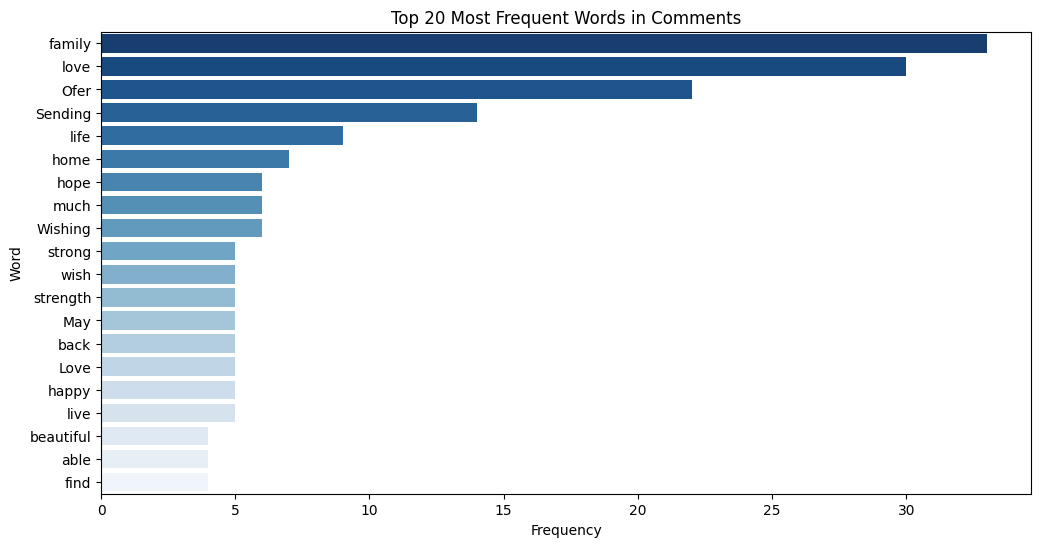

In [79]:
# Count word frequencies
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(20)  # Get top 20 words

# Convert to DataFrame
freq_df = pd.DataFrame(common_words, columns=["word", "count"])

# Plot using seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x="count", y="word", data=freq_df, palette="Blues_r")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 20 Most Frequent Words in Comments")
plt.show()

/tmp/ipython-input-80-723027712.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




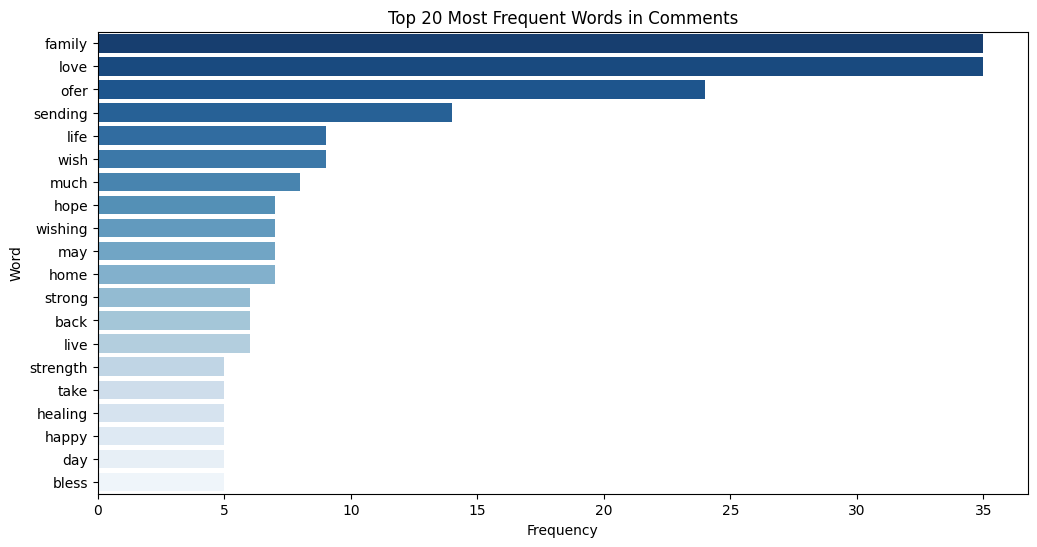

In [80]:
word_counts_lemmatized = Counter(filtered_lemmatized_words)
common_words_lemmatized = word_counts_lemmatized.most_common(20)  # Get top 20 words

# Convert to DataFrame for plotting
freq_df = pd.DataFrame(common_words_lemmatized, columns=["word", "count"])

plt.figure(figsize=(12, 6))
sns.barplot(x="count", y="word", data=freq_df, palette="Blues_r")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 20 Most Frequent Words in Comments")
plt.show()



In [81]:
df_en_nltk_positive = df_en[df_en['Sentiment_nltk'].str.contains('Positive', case=False, na=False)]
df_en_nltk_negative = df_en[df_en['Sentiment_nltk'].str.contains('Negative', case=False, na=False)]
df_en_nltk_neutral = df_en[df_en['Sentiment_nltk'].str.contains('Neutral', case=False, na=False)]

df_en_distilbert_positive = df_en[df_en['Sentiment_distilbert'].str.contains('Positive', case=False, na=False)]
df_en_distilbert_negative = df_en[df_en['Sentiment_distilbert'].str.contains('Negative', case=False, na=False)]
df_en_distilbert_neutral = df_en[df_en['Sentiment_distilbert'].str.contains('Neutral', case=False, na=False)]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/tmp/ipython-input-82-617857524.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-82-617857524.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-82-617857524.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-82-617857524.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the 

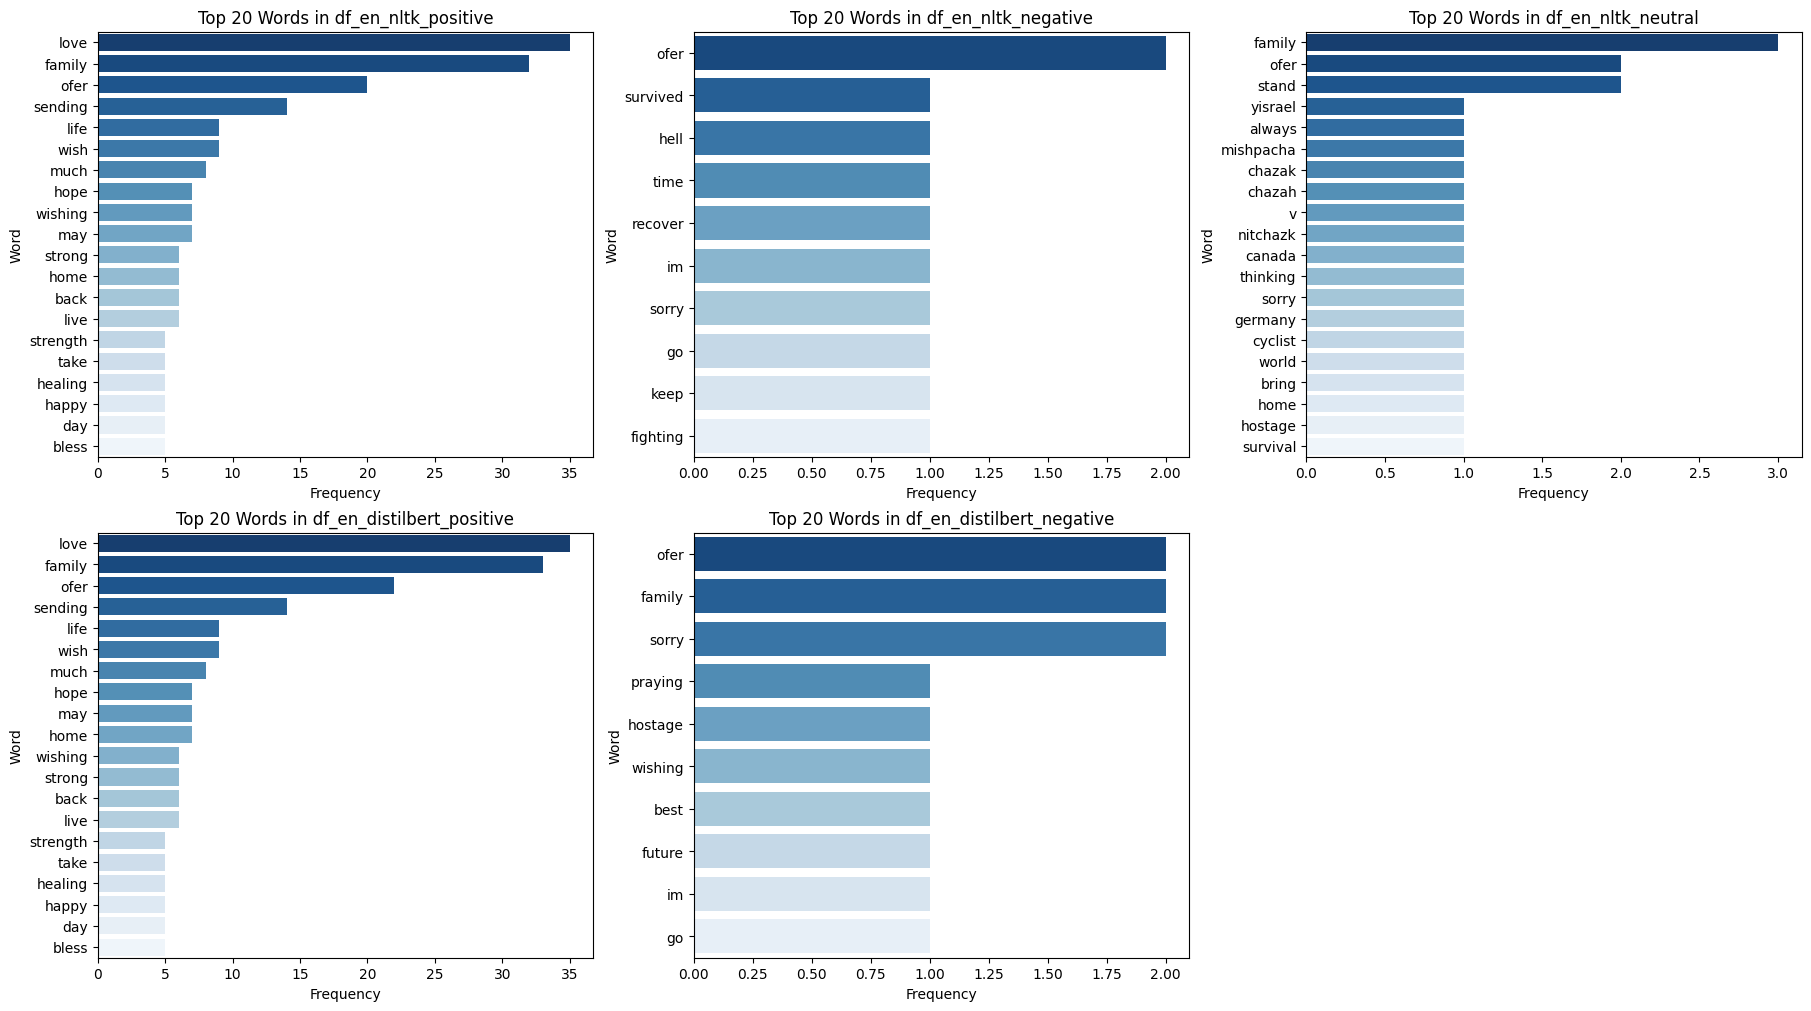

In [82]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')
stop_words_set = set(stopwords.words("english"))

def preprocess_text(df, token_column, lemmatized_column):
    words_list = sum(df[token_column], [])
    lemmatized_tokens_list = sum(df[lemmatized_column], [])

    filtered_words = [w for w in words_list if w.isalnum() and w.lower() not in stop_words_set]
    filtered_lemmatized_words = [w for w in lemmatized_tokens_list if w.isalnum() and w.lower() not in stop_words_set]

    return filtered_lemmatized_words

def get_top_words(filtered_words, top_n=20):
    word_counts = Counter(filtered_words)
    return word_counts.most_common(top_n)

def plot_top_words(subplot_ax, common_words, title):
    freq_df = pd.DataFrame(common_words, columns=["word", "count"])

    sns.barplot(ax=subplot_ax, x="count", y="word", data=freq_df, palette="Blues_r")
    subplot_ax.set_xlabel("Frequency")
    subplot_ax.set_ylabel("Word")
    subplot_ax.set_title(title)

# List of DataFrames to process
dfs = {
    "df_en_nltk_positive": df_en_nltk_positive,
    "df_en_nltk_negative": df_en_nltk_negative,
    "df_en_nltk_neutral": df_en_nltk_neutral,
    "df_en_distilbert_positive": df_en_distilbert_positive,
    "df_en_distilbert_negative": df_en_distilbert_negative
}

# Set up subplots (2 rows: first row with 3 plots, second row with 2 plots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes = axes.flatten()

# Process each DataFrame and plot in a different subplot
for i, (name, curr_df) in enumerate(dfs.items()):
    filtered_words = preprocess_text(curr_df, "tokens", "lemmatized_tokens")
    common_words = get_top_words(filtered_words)
    plot_top_words(axes[i], common_words, title=f"Top 20 Words in {name}")

# Hide any unused subplots
for j in range(len(dfs), len(axes)):
    fig.delaxes(axes[j])

plt.show()

##Word cloud
of negative | positive comments

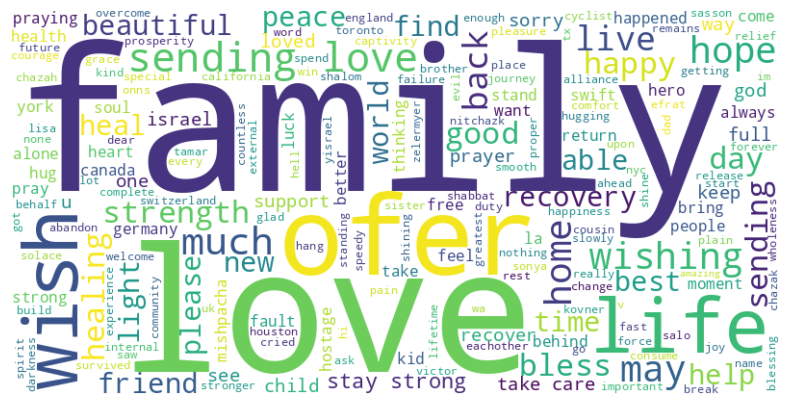

In [83]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(filtered_lemmatized_words))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

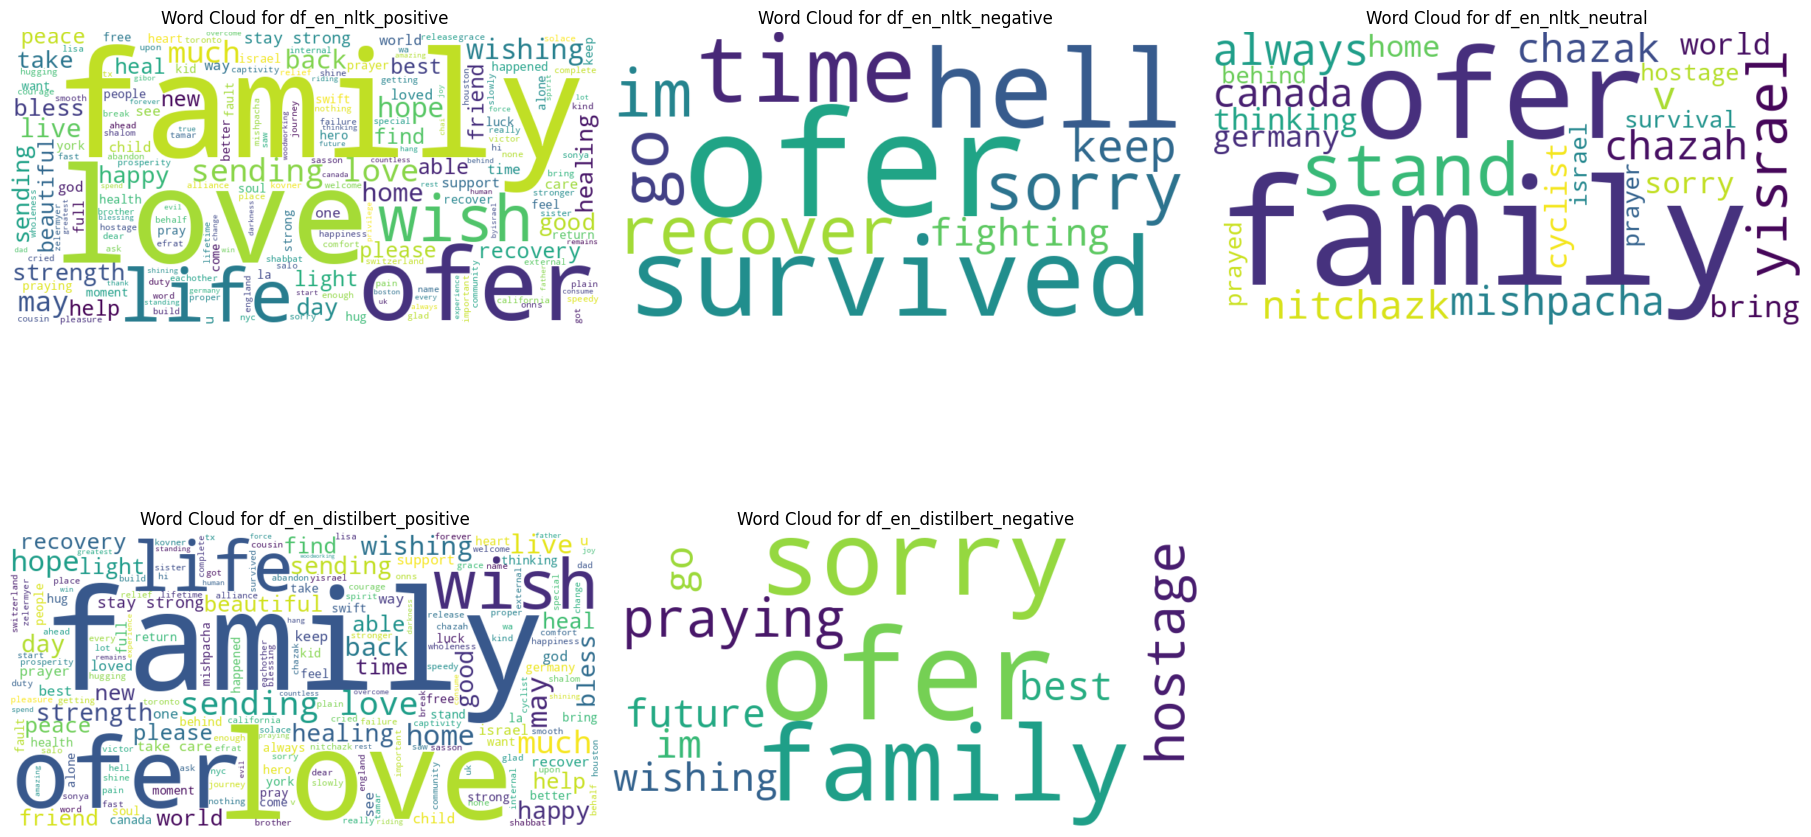

In [84]:
def plot_wordcloud(subplot_ax, filtered_words, title):
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(filtered_words))

    subplot_ax.imshow(wordcloud, interpolation="bilinear")
    subplot_ax.axis("off")
    subplot_ax.set_title(title)

# List of DataFrames to process
dfs = {
    "df_en_nltk_positive": df_en_nltk_positive,
    "df_en_nltk_negative": df_en_nltk_negative,
    "df_en_nltk_neutral": df_en_nltk_neutral,
    "df_en_distilbert_positive": df_en_distilbert_positive,
    "df_en_distilbert_negative": df_en_distilbert_negative
}

# Set up subplots (2 rows: first row with 3 plots, second row with 2 plots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes = axes.flatten()

# Process each DataFrame and plot in a different subplot
for i, (name, df) in enumerate(dfs.items()):
    filtered_words = preprocess_text(df, "tokens", "lemmatized_tokens")
    plot_wordcloud(axes[i], filtered_words, title=f"Word Cloud for {name}")

# Hide any unused subplots
for j in range(len(dfs), len(axes)):
    fig.delaxes(axes[j])

plt.show()

In [125]:
filtered_words = preprocess_text(df_en_nltk_positive, "tokens", "lemmatized_tokens")
common_words = get_top_words(filtered_words, top_n=50)
common_words = [word for word, count in common_words]


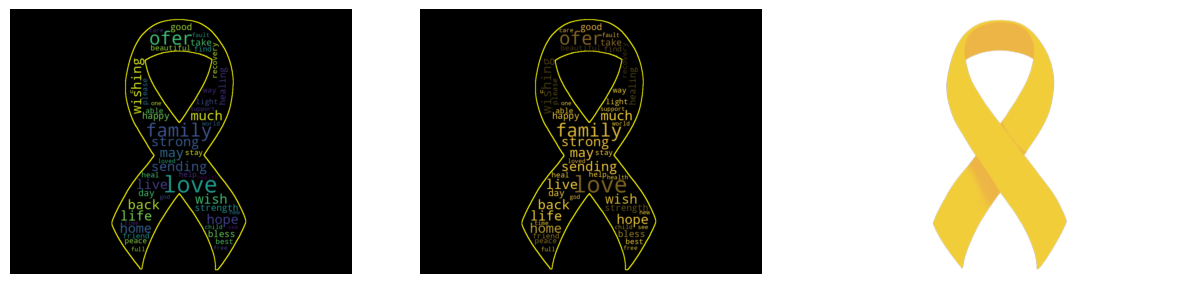

In [126]:
from wordcloud import ImageColorGenerator
from PIL import Image


coloring = np.array(Image.open("/content/Yellow_Ribbon.png"))
mask = np.array(Image.open("/content/Yellow_Ribbon.png").convert("L"))
mask = np.where(mask < 128, 255, 0).astype(np.uint8)


wc = WordCloud(background_color="black", mask=mask, prefer_horizontal=0.99,
                      contour_width=4, contour_color='yellow').generate(" ".join(common_words))

# create coloring from image
image_colors = ImageColorGenerator(coloring)

# show
fig, axes = plt.subplots(1, 3, figsize=(15, 15))
axes[0].imshow(wc, interpolation="bilinear")
# recolor wordcloud and show
# we could also give color_func=image_colors directly in the constructor
axes[1].imshow(wc.recolor(color_func=image_colors), interpolation="bilinear")
axes[2].imshow(coloring, cmap=plt.cm.gray, interpolation="bilinear")
for ax in axes:
    ax.set_axis_off()
plt.show()

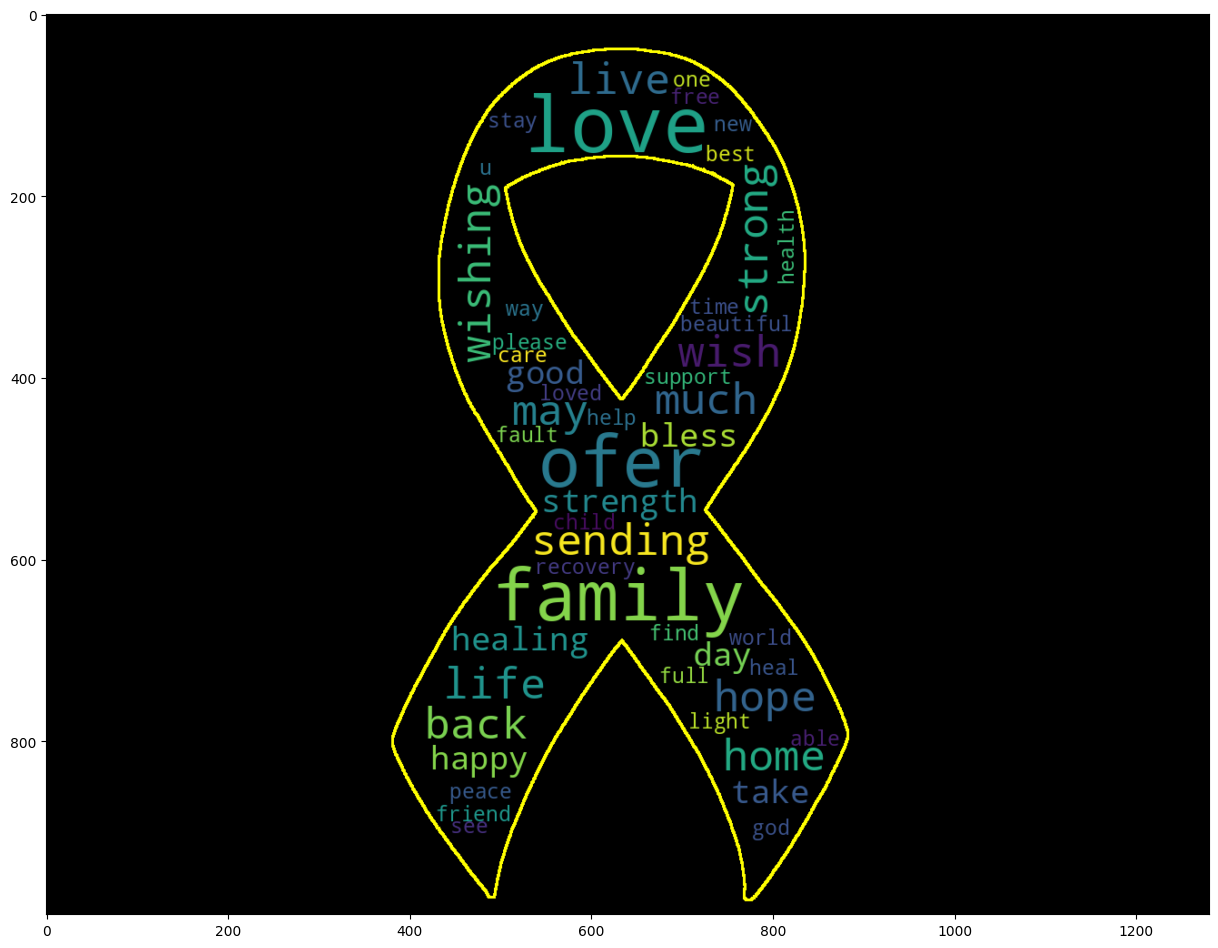

In [127]:
from wordcloud import ImageColorGenerator


coloring = np.array(Image.open("/content/Yellow_Ribbon.png"))
mask = np.array(Image.open("/content/Yellow_Ribbon.png").convert("L"))
mask = np.where(mask < 128, 255, 0).astype(np.uint8)


wc = WordCloud(background_color="black", mask=mask, prefer_horizontal=0.99,
                      contour_width=4, contour_color='yellow').generate(" ".join(common_words))

# create coloring from image
image_colors = ImageColorGenerator(coloring)

# show
fig = plt.figure(figsize=(15, 15))

# plt.imshow(wc.recolor(color_func=image_colors), interpolation="bilinear")
plt.imshow(wc, interpolation="bilinear")

plt.show()